In [55]:
from fredapi import Fred
import yfinance as yf
from fred_api_key import API_KEY
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume,Asset_Returns,FedFunds,Inflation,12_ema,27_ema,MACD,Signal,MACD_hist,Econ_Strategy,TA_Strategy,Strategy,Strategy_Returns
1993-02-02,24.537842,44.343750,44.375000,44.125000,44.218750,201300.0,0.009246,3.18,3.24675,44.300781,44.298611,0.002170,0.001206,0.000965,1,-1,-1.0,-0.002119
1993-02-03,24.797235,44.812500,44.843750,44.375000,44.406250,529400.0,0.019915,3.56,3.24675,44.500505,44.482747,0.017758,0.007990,0.009769,-1,-1,0.0,-0.002119
1993-02-04,24.900969,45.000000,45.093750,44.468750,44.968750,531500.0,0.024182,3.08,3.24675,44.658176,44.626769,0.031407,0.015922,0.015485,1,-1,-1.0,-0.006294
1993-02-05,24.883686,44.968750,45.062500,44.718750,44.968750,492100.0,0.023471,2.87,3.24675,44.742558,44.705659,0.036899,0.022162,0.014737,1,-1,0.0,-0.006294
1993-02-06,24.883686,44.968750,45.062500,44.718750,44.968750,492100.0,0.023471,2.87,3.24675,44.797535,44.758012,0.039522,0.026868,0.012654,1,-1,0.0,-0.006294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,685.239990,685.239990,685.539978,682.119995,682.729980,63339800.0,14.595789,4.12,3.02270,673.125810,668.391478,4.734332,2.966672,1.767660,-1,1,0.0,-0.781544
2025-10-28,687.059998,687.059998,688.909973,684.830017,687.049988,61738100.0,14.637212,4.12,3.02270,675.269531,669.724944,5.544587,3.482255,2.062332,-1,1,0.0,-0.781544
2025-10-29,687.390015,687.390015,689.700012,682.869995,688.719971,85657100.0,14.644723,4.12,3.02270,677.134221,670.986735,6.147486,4.015301,2.132185,-1,1,0.0,-0.781544
2025-10-30,679.830017,679.830017,685.940002,679.830017,683.900024,76335800.0,14.472660,3.87,3.02270,677.548959,671.618398,5.930561,4.398353,1.532208,-1,1,0.0,-0.781544


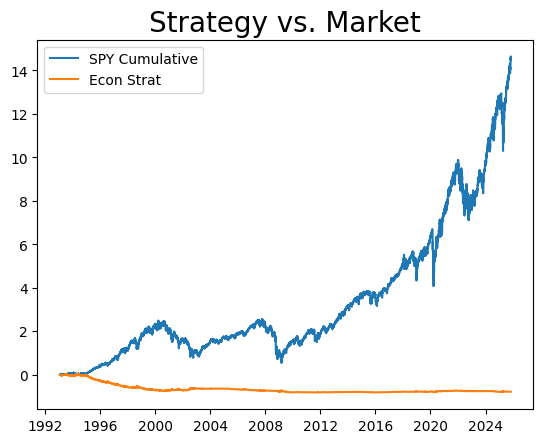

In [56]:
TICKER = 'SPY'
INTERVAL = '1d'
PERIOD = '730d' if INTERVAL == '1h' else 'max'

MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9

LOOKBACK = 10000
fred = Fred(api_key=API_KEY)

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    df = yf.download(ticker, interval=interval, auto_adjust=False, period=PERIOD, group_by='column')
    df.columns = df.columns.get_level_values(0)

    # only return the subset of data you are interested in
    df = df.iloc[-lookback:, :]
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1

    return df.dropna()

def add_interest_rates(df):
    fedfunds = pd.DataFrame(fred.get_series('DFF'), columns=['FedFunds'])
    combined = pd.concat([df, fedfunds], axis=1) 
    return combined

def add_inflation(df):
    inflation = pd.DataFrame(fred.get_series('CPIAUCSL', units='pc1'), columns=['Inflation'])
    combined = pd.concat([df, inflation], axis=1).ffill() 
    return combined

def add_MACD(df, fast=MACD_FAST, slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    # macd line is the difference betweent he fast and slow
    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    # macd signal is a 9-period moving average of this line
    df['Signal'] = df['MACD'].ewm(span=span).mean()

    # MACD histogram is almost always what is used in TA
    df['MACD_hist'] = df['MACD'] - df['Signal']

    return df

def add_economic_strategy(df):
    df['Econ_Strategy'] = np.where(df['Inflation'] > df['FedFunds'], 1, -1)
    return df

def add_TA_strategy(df):
    df['TA_Strategy'] = np.where(df['MACD'] > 1, 1, -1)
    return df

def add_full_strategy(df):
    combined = df['Econ_Strategy'] + df['TA_Strategy']

    df['Strategy'] = np.where(combined > 0, 1,
                       np.where(combined < 0, -1, 0))
    
    df['Strategy'] = df['Strategy'].shift()

    return df

def test_strategy(df):

    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Econ Strat'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_interest_rates(df)
    df = add_inflation(df)
    df = add_MACD(df)
    df = add_economic_strategy(df)
    df = add_TA_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)
    return df

df = main()
df = df.dropna()

df

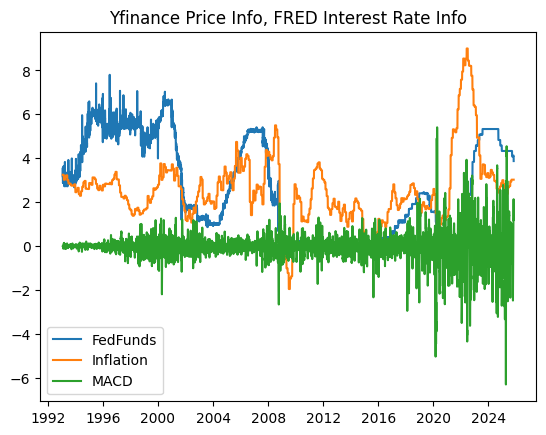

In [57]:
plt.plot(df['FedFunds'])
plt.plot(df['Inflation'])
plt.plot(df['MACD_hist'])
plt.legend(['FedFunds', 'Inflation', 'MACD'])
plt.title('Yfinance Price Info, FRED Interest Rate Info');